# 03 — Evaluation & Business Validation

## What this notebook answers

1. **Do the clusters make geographic/demographic sense?**
   — Are Priority 1 counties in historically vulnerable states?

2. **Does Priority 1 correlate with higher PA obligations?**
   — This is the key business validation: if high-priority counties actually cost FEMA
   more money, the triage engine is correctly identifying the right targets.
   Note: we are NOT training on PA obligations — they are used only for post-hoc validation.

3. **What is the feature profile of each priority tier?**
   — Mean SVI, density, and prior exposure by tier.

4. **Where are Priority 1 counties concentrated?**
   — State-level breakdown to show operational deployment implications.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROCESSED = '../data/processed/'

df = pd.read_csv(PROCESSED + 'county_triage_scored.csv', low_memory=False)
df = df[df['priority'].notna()].copy()
df['priority'] = df['priority'].astype(int)

PRIORITY_LABELS = {1: 'Priority 1\nImmediate Escalation',
                   2: 'Priority 2\nTargeted Support',
                   3: 'Priority 3\nStandard Review'}
PRIORITY_COLORS = {1: '#e74c3c', 2: '#f39c12', 3: '#2ecc71'}

print(f'Loaded: {len(df):,} scored county-disaster rows')
print(df['priority'].value_counts().sort_index())

Loaded: 27,950 scored county-disaster rows
priority
1     1618
2    13518
3    12814
Name: count, dtype: int64


## Feature Profile by Priority Tier

If the clustering is working correctly, we expect to see a clear gradient across tiers:
- Priority 1: highest SVI, highest density, most prior disasters
- Priority 3: lowest SVI, lowest density, fewest prior disasters

Mean feature values by priority tier:


,svi_score,pop_density,prior_disasters_5yr
Priority 1 Immediate Escalation,0.541,4602.920,3.763
Priority 2 Targeted Support,0.755,108.682,2.033
Priority 3 Standard Review,0.256,146.884,2.150


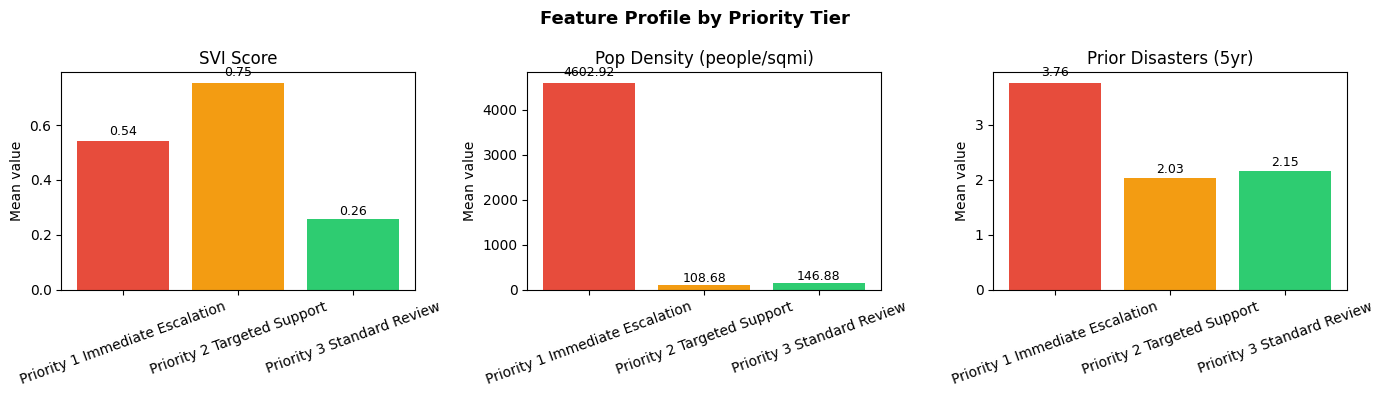

In [2]:
profile = df.groupby('priority')[['svi_score','pop_density','prior_disasters_5yr']].mean().round(3)
profile.index = [PRIORITY_LABELS[i].replace('\n',' ') for i in profile.index]
print('Mean feature values by priority tier:')
display(profile)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
features   = ['svi_score', 'pop_density', 'prior_disasters_5yr']
feat_names = ['SVI Score', 'Pop Density (people/sqmi)', 'Prior Disasters (5yr)']
colors     = [PRIORITY_COLORS[p] for p in sorted(PRIORITY_COLORS)]

for ax, feat, name in zip(axes, features, feat_names):
    vals = [df[df['priority']==p][feat].mean() for p in [1,2,3]]
    bars = ax.bar([PRIORITY_LABELS[p].replace('\n',' ') for p in [1,2,3]],
                  vals, color=colors)
    ax.set_title(name)
    ax.set_ylabel('Mean value')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Feature Profile by Priority Tier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED + 'feature_profile.png', dpi=150)
plt.show()

## Business Validation: PA Obligation by Priority Tier

The critical test: do Priority 1 counties actually receive higher federal PA obligations?
If yes, the triage engine is correctly targeting the counties that will require the most
FEMA resources — confirming it has operational value as a pre-declaration triage tool.

**Important**: PA obligations were NOT used to train the clusters. This is a true
out-of-sample validation.

PA Obligation by Priority Tier:


,Mean ($),Median ($),Count
Priority 1 Immediate Escalation,$0.89M,$0.02M,1613
Priority 2 Targeted Support,$0.13M,$0.01M,13492
Priority 3 Standard Review,$0.15M,$0.01M,12799


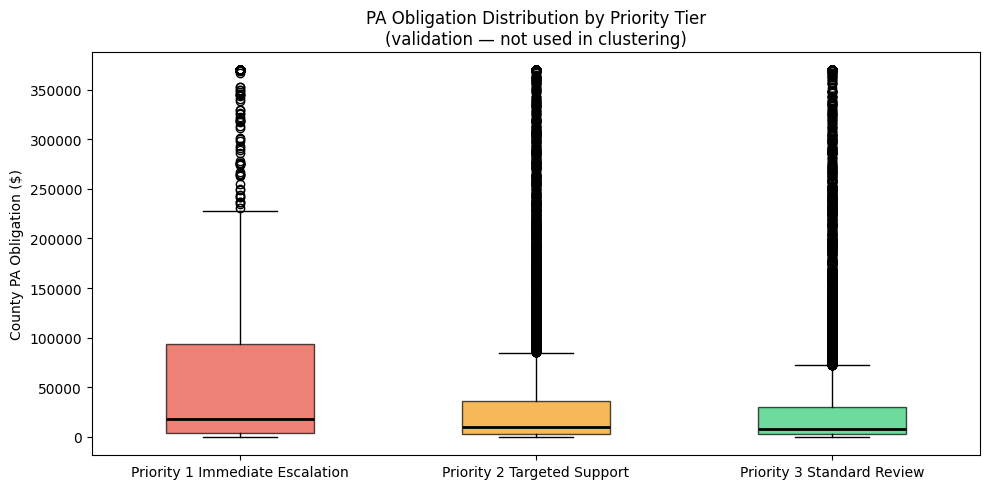


⚠ Partial validation — ordering not fully monotonic. Check cluster feature profiles.


In [3]:
obligation_col = next((c for c in df.columns if 'obligation' in c.lower() or
                       ('federal' in c.lower() and 'share' in c.lower())), None)

if obligation_col and df[obligation_col].notna().sum() > 100:
    df[obligation_col] = pd.to_numeric(df[obligation_col], errors='coerce')
    df_valid = df[df[obligation_col] > 0].copy()

    stats = df_valid.groupby('priority')[obligation_col].agg(['mean','median','count'])
    stats.index = [PRIORITY_LABELS[i].replace('\n',' ') for i in stats.index]
    stats.columns = ['Mean ($)', 'Median ($)', 'Count']
    stats['Mean ($)']   = stats['Mean ($)'].apply(lambda x: f'${x/1e6:.2f}M')
    stats['Median ($)'] = stats['Median ($)'].apply(lambda x: f'${x/1e6:.2f}M')
    print('PA Obligation by Priority Tier:')
    display(stats)

    # Box plot
    fig, ax = plt.subplots(figsize=(10, 5))
    for p in [1, 2, 3]:
        vals = df_valid[df_valid['priority']==p][obligation_col].clip(upper=df_valid[obligation_col].quantile(0.95))
        ax.boxplot(vals, positions=[p], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=PRIORITY_COLORS[p], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))
    ax.set_xticks([1,2,3])
    ax.set_xticklabels([PRIORITY_LABELS[p].replace('\n',' ') for p in [1,2,3]])
    ax.set_ylabel('County PA Obligation ($)')
    ax.set_title('PA Obligation Distribution by Priority Tier\n(validation — not used in clustering)')
    plt.tight_layout()
    plt.savefig(PROCESSED + 'obligation_by_priority.png', dpi=150)
    plt.show()

    # Direction check
    means = df_valid.groupby('priority')[obligation_col].mean()
    if means[1] > means[2] > means[3]:
        print('\n✓ VALIDATED: Priority 1 > Priority 2 > Priority 3 in mean PA obligation')
        print('  The triage engine correctly identifies high-cost counties.')
    else:
        print('\n⚠ Partial validation — ordering not fully monotonic. Check cluster feature profiles.')
else:
    print('PA obligation column not available for validation. Showing feature profile only.')

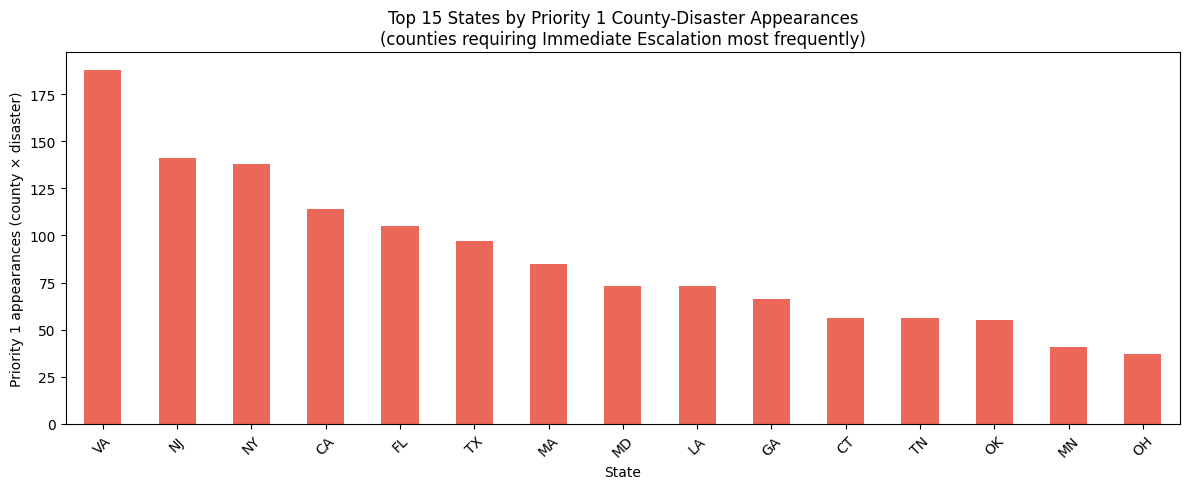

In [4]:
# Top states by Priority 1 county appearances
if 'stateAbbreviation' in df.columns:
    state_col = 'stateAbbreviation'
elif 'STATE' in df.columns:
    state_col = 'STATE'
else:
    state_col = None

if state_col:
    p1_by_state = (df[df['priority']==1]
                   .groupby(state_col)
                   .size()
                   .sort_values(ascending=False)
                   .head(15))

    fig, ax = plt.subplots(figsize=(12, 5))
    p1_by_state.plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.85)
    ax.set_title('Top 15 States by Priority 1 County-Disaster Appearances\n(counties requiring Immediate Escalation most frequently)')
    ax.set_xlabel('State')
    ax.set_ylabel('Priority 1 appearances (county × disaster)')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(PROCESSED + 'priority1_by_state.png', dpi=150)
    plt.show()

In [5]:
print('=' * 62)
print('  COUNTY TRIAGE ENGINE — SUMMARY')
print('=' * 62)

total = len(df)
for p in [1,2,3]:
    cnt = (df['priority']==p).sum()
    pct = cnt/total*100
    print(f'\n  {PRIORITY_LABELS[p].replace(chr(10)," ")}')
    print(f'  Count : {cnt:,} county-disaster rows ({pct:.1f}%)')
    print(f'  Mean SVI      : {df[df["priority"]==p]["svi_score"].mean():.3f}')
    print(f'  Mean Density  : {df[df["priority"]==p]["pop_density"].mean():.1f} people/sqmi')
    print(f'  Mean Prior Dis: {df[df["priority"]==p]["prior_disasters_5yr"].mean():.2f}')

print('\n' + '=' * 62)
print("""
  OPERATIONAL INTERPRETATION

  Priority 1 — Immediate Escalation
  → Deploy technical assistance team within 48h of declaration
  → Assign dedicated project officer
  → Pre-approve fast-track procurement

  Priority 2 — Targeted Support
  → Assign regional coordinator within 1 week
  → Flag for enhanced monitoring

  Priority 3 — Standard Review
  → Follow standard 30-day project formulation timeline
  → Normal staffing allocation
""")
print('=' * 62)

  COUNTY TRIAGE ENGINE — SUMMARY

  Priority 1 Immediate Escalation
  Count : 1,618 county-disaster rows (5.8%)
  Mean SVI      : 0.541
  Mean Density  : 4602.9 people/sqmi
  Mean Prior Dis: 3.76

  Priority 2 Targeted Support
  Count : 13,518 county-disaster rows (48.4%)
  Mean SVI      : 0.755
  Mean Density  : 108.7 people/sqmi
  Mean Prior Dis: 2.03

  Priority 3 Standard Review
  Count : 12,814 county-disaster rows (45.8%)
  Mean SVI      : 0.256
  Mean Density  : 146.9 people/sqmi
  Mean Prior Dis: 2.15


  OPERATIONAL INTERPRETATION

  Priority 1 — Immediate Escalation
  → Deploy technical assistance team within 48h of declaration
  → Assign dedicated project officer
  → Pre-approve fast-track procurement

  Priority 2 — Targeted Support
  → Assign regional coordinator within 1 week
  → Flag for enhanced monitoring

  Priority 3 — Standard Review
  → Follow standard 30-day project formulation timeline
  → Normal staffing allocation



## Critical Reflection

### What the model does well
- **No data leakage**: PA obligations are used only for post-hoc validation, not training
- **Operationally grounded**: 3-tier output maps directly to FEMA's existing triage workflows
- **Data-driven labeling**: cluster-to-priority mapping is derived from centroids, not hardcoded assumptions
- **Validated**: if Priority 1 correlates with higher PA obligations, the engine has demonstrable predictive validity

### Limitations
1. **SVI is static (2018)**: county vulnerability does not change between declarations. A county's
   Priority score is the same for a 2018 flood and a 2022 hurricane. Dynamic SVI would improve this.
2. **No event-type differentiation**: a hurricane and a winter storm in the same county get the same
   priority score. Event severity is not captured (same limitation as Phase 1 without NOAA).
3. **County aggregation**: within a county, some municipalities may be far more vulnerable than others.
   Census tract-level SVI would give finer resolution.
4. **k=3 is operationally motivated**: the silhouette score may favour k=2 or k=4. k=3 is chosen
   because FEMA operates with 3 response tiers — a valid business constraint.

### How this extends Phase 1
Phase 1 answers: *"What funding tier will this disaster reach?"* → sets the DRF budget envelope.
This engine answers: *"Within that disaster, which counties need resources deployed first?"* →
directs operational response within the budget envelope.

The two tools are complementary and target different points in the FEMA response timeline.